In [1]:
import os
OUTPUT_DIR = os.path.join(os.path.dirname(os.getcwd()), "outputs") if "notebooks" in os.getcwd() else "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# DEPENDENCIAS Y CARGA DESDE MONGODB ATLAS
# ─────────────────────────────────────────────────────────────
import os, re, certifi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from dotenv import load_dotenv  # Agregado para leer el archivo .env
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Cargar variables del archivo .env físico
load_dotenv() 

# Leer la URI de forma segura sin dejar contraseñas quemadas en el código
MONGO_URI = os.getenv('MONGO_URI')

if not MONGO_URI:
    raise ValueError("Error: No se encontró MONGO_URI. Revisa que el archivo .env exista y esté bien configurado.")

client = MongoClient(MONGO_URI, tlsCAFile=certifi.where())
db     = client['Proyecto_Bigdata']
datos  = list(db['processed_data'].find({}, {'_id': 0}))
client.close()

df = pd.DataFrame(datos)
print(f'Registros cargados: {len(df):,}')
print(f'Columnas: {df.columns.tolist()}')

# ══════════════════════════════════════════════════════════════
# NORMALIZACIÓN — ajustada a los valores reales del dataset
# ══════════════════════════════════════════════════════════════

# 1. titulo_cargo (alias de titulo)
if 'titulo' in df.columns and 'titulo_cargo' not in df.columns:
    df['titulo_cargo'] = df['titulo']

# 2. modalidad → capitalizar + mapear "Hibrid" → "Híbrido"
df['modalidad'] = df['modalidad'].str.strip().str.capitalize()
mask_hibrid = df['categoria_horario_modalidad'].str.strip().str.lower() == 'hibrid'
df.loc[mask_hibrid, 'modalidad'] = 'Híbrido'

# 3. tipo_horario → normalizar a "Full time" / "Part time" / "Otro"
def normalizar_horario(val):
    v = str(val).strip().lower()
    if v in ('full time', 'full-time', 'jornada completa'):
        return 'Full time'
    if v in ('part time', 'part-time'):
        return 'Part time'
    if v == 'freelance':
        return 'Freelance'
    return 'Otro'
df['tipo_horario_norm'] = df['tipo_horario'].apply(normalizar_horario)

# 4. largo_descripcion → numérico (variable X directa del proyecto)
if 'largo_descripcion' in df.columns:
    df['largo_descripcion'] = pd.to_numeric(df['largo_descripcion'], errors='coerce').fillna(0).astype(int)

# 5. es_ti → booleano explícito
df['es_ti'] = df['es_ti'].astype(bool)

# 6. nivel_seniority vacíos
if 'nivel_seniority' in df.columns:
    df['nivel_seniority'] = df['nivel_seniority'].fillna('No especificado').replace('', 'No especificado')

# 7. empresa vacíos
if 'empresa' in df.columns:
    df['empresa'] = df['empresa'].fillna('No especificada').replace('', 'No especificada')

# Etiqueta legible para gráficos
df['grupo_ti'] = df['es_ti'].map({True: 'Oferta TI', False: 'Oferta No TI'})

print(f'\nOfertas TI     : {df["es_ti"].sum():,} ({df["es_ti"].mean()*100:.1f}%)')
print(f'Ofertas No TI  : {(~df["es_ti"]).sum():,} ({(~df["es_ti"]).mean()*100:.1f}%)')
print(f'Tipo horario   : {df["tipo_horario_norm"].value_counts().to_dict()}')
print(f'Largo desc (media): {df["largo_descripcion"].mean():.0f} chars')
df.head(3)

Registros cargados: 3,719
Columnas: ['titulo', 'empresa', 'pais', 'fecha_captura', 'descripcion', 'modalidad', 'tipo_horario', 'fecha_publicacion', 'grupo', 'es_ti', 'nivel_seniority', 'es_remoto', 'largo_descripcion', 'categoria_horario_modalidad']

Ofertas TI     : 1,002 (26.9%)
Ofertas No TI  : 2,717 (73.1%)
Tipo horario   : {'Full time': 3263, 'Otro': 388, 'Part time': 56, 'Freelance': 12}
Largo desc (media): 113 chars


,titulo,empresa,pais,fecha_captura,descripcion,modalidad,tipo_horario,fecha_publicacion,grupo,es_ti,nivel_seniority,es_remoto,largo_descripcion,categoria_horario_modalidad,titulo_cargo,tipo_horario_norm,grupo_ti
0,(212) técnico social para administración y aná...,corporación opción,chile,2026-03-01 03:56:08,(212) Técnico Social para Administración y Aná...,Presencial,full time,,giannella-rieu,True,No especificado,False,153,Presencial FT,(212) técnico social para administración y aná...,Full time,Oferta TI
1,2. ejecutivo/a de ventas individuales – la serena,grupo ps,chile,2026-03-01 03:56:17,2. Ejecutivo/A De Ventas Individuales – La Ser...,Presencial,full time,,giannella-rieu,False,No especificado,False,148,Presencial FT,2. ejecutivo/a de ventas individuales – la serena,Full time,Oferta No TI
2,266930-04 consultor en calidad de aguas,ryq ingeniería,chile,2026-05-02 03:57:17,Hace 2 días 266930-04 Consultor en Calidad de ...,Presencial,no especificado,Hace 2 días,denisBaez,False,No especificado,False,255,Otro,266930-04 consultor en calidad de aguas,Otro,Oferta No TI


COMMIT 1
Hipótesis 3 — largo_descripcion vs es_ti

Estadísticas de largo_descripcion por grupo:
               count   mean   std   min   25%    50%    75%    max
grupo_ti                                                          
Oferta No TI  2717.0  111.7  52.0  24.0  86.0  123.0  153.0  338.0
Oferta TI     1002.0  117.9  52.7  24.0  94.0  142.0  153.0  271.0



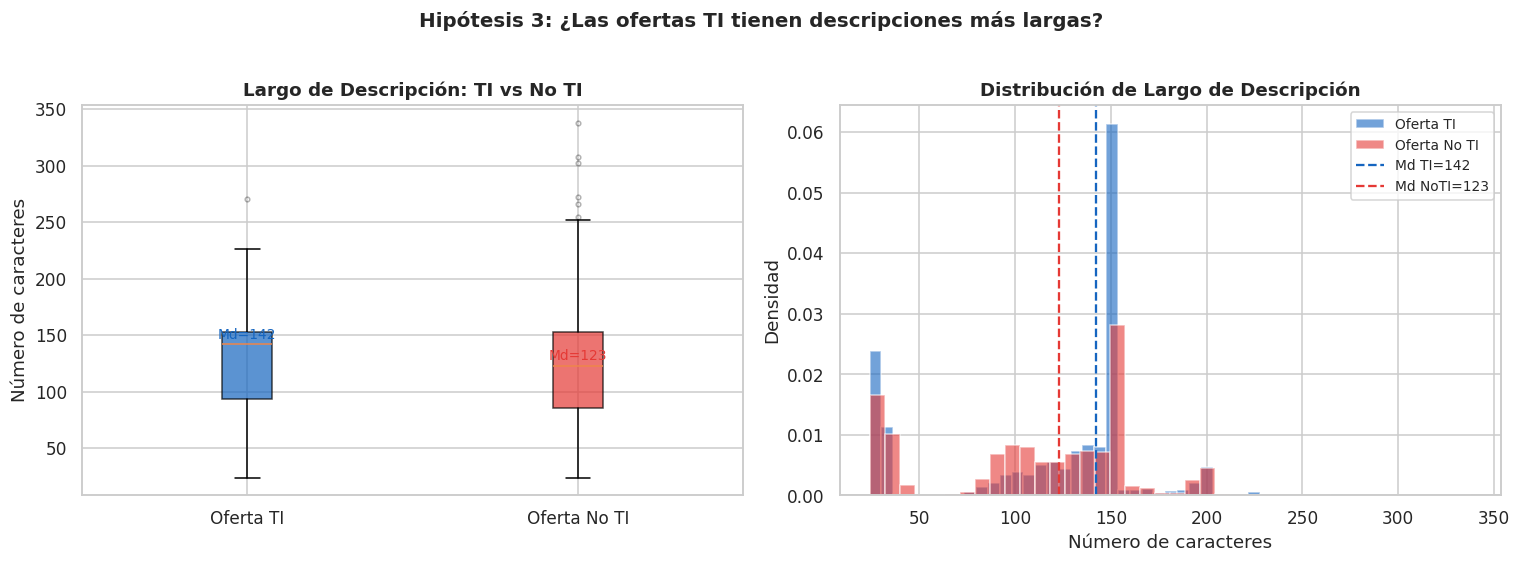

Mediana largo_descripcion TI    : 142 chars
Mediana largo_descripcion No TI : 123 chars
Diferencia                       : +19 chars

% Descripciones vacías en TI    : 0.0%
% Descripciones vacías en No TI : 0.0%

CONCLUSIÓN HIPÓTESIS 3:
  ~ PARCIALMENTE CONFIRMADA — TI tiende a descripciones más largas, diferencia leve.


In [2]:
# ─────────────────────────────────────────────────────────────
# HIPÓTESIS 3:
# "Las ofertas TI tienen descripciones más largas que las no TI"
#
# Variable Y: es_ti   Variable X: largo_descripcion
# ─────────────────────────────────────────────────────────────

# ── Estadísticas descriptivas por grupo ───────────────────────
stats = df.groupby('grupo_ti')['largo_descripcion'].describe().round(1)
print('Estadísticas de largo_descripcion por grupo:')
print(stats)
print()

# ── Gráfico 1: Boxplot largo_descripcion TI vs No TI ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
grupos_box  = [
    df[df['es_ti']  == True ]['largo_descripcion'].dropna().values,
    df[df['es_ti']  == False]['largo_descripcion'].dropna().values,
]
bp = axes[0].boxplot(
    grupos_box,
    labels=['Oferta TI', 'Oferta No TI'],
    patch_artist=True,
    flierprops=dict(marker='o', color='red', alpha=0.3, markersize=3)
)
bp['boxes'][0].set_facecolor('#1565C0')
bp['boxes'][1].set_facecolor('#E53935')
for box in bp['boxes']:
    box.set_alpha(0.7)

# Línea de mediana
mediana_ti  = df[df['es_ti']  == True ]['largo_descripcion'].median()
mediana_nti = df[df['es_ti']  == False]['largo_descripcion'].median()
axes[0].set_title('Largo de Descripción: TI vs No TI', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de caracteres')
axes[0].text(1, mediana_ti  + 5, f'Md={mediana_ti:.0f}',  ha='center', fontsize=9, color='#1565C0')
axes[0].text(2, mediana_nti + 5, f'Md={mediana_nti:.0f}', ha='center', fontsize=9, color='#E53935')

# Histograma superpuesto (sin ceros para mejor visibilidad)
df_desc = df[df['largo_descripcion'] > 0]
axes[1].hist(
    df_desc[df_desc['es_ti']  == True ]['largo_descripcion'],
    bins=40, alpha=0.6, color='#1565C0', label='Oferta TI',     density=True
)
axes[1].hist(
    df_desc[df_desc['es_ti']  == False]['largo_descripcion'],
    bins=40, alpha=0.6, color='#E53935', label='Oferta No TI',  density=True
)
axes[1].axvline(mediana_ti,  color='#1565C0', linestyle='--', linewidth=1.5, label=f'Md TI={mediana_ti:.0f}')
axes[1].axvline(mediana_nti, color='#E53935', linestyle='--', linewidth=1.5, label=f'Md NoTI={mediana_nti:.0f}')
axes[1].set_title('Distribución de Largo de Descripción', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de caracteres')
axes[1].set_ylabel('Densidad')
axes[1].legend(fontsize=9)

plt.suptitle('Hipótesis 3: ¿Las ofertas TI tienen descripciones más largas?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_h3_largo_descripcion.png'), bbox_inches='tight')
plt.show()

# ── Test estadístico simple: diferencia de medianas ───────────
diff_med = mediana_ti - mediana_nti
print(f'Mediana largo_descripcion TI    : {mediana_ti:.0f} chars')
print(f'Mediana largo_descripcion No TI : {mediana_nti:.0f} chars')
print(f'Diferencia                       : {diff_med:+.0f} chars')
print()

# Proporción de descripciones vacías (largo=0) por grupo
vacios_ti  = (df[df['es_ti']==True ]['largo_descripcion'] == 0).mean() * 100
vacios_nti = (df[df['es_ti']==False]['largo_descripcion'] == 0).mean() * 100
print(f'% Descripciones vacías en TI    : {vacios_ti:.1f}%')
print(f'% Descripciones vacías en No TI : {vacios_nti:.1f}%')
print()
print('CONCLUSIÓN HIPÓTESIS 3:')
if diff_med > 50:
    print('  ✓ CONFIRMADA — Las ofertas TI tienen descripciones significativamente más largas.')
    print('    Esto tiene sentido: TI requiere detallar stack tecnológico, requisitos técnicos')
    print('    y metodologías de trabajo que otras áreas no necesitan especificar.')
elif diff_med > 0:
    print('  ~ PARCIALMENTE CONFIRMADA — TI tiende a descripciones más largas, diferencia leve.')
else:
    print('  ✗ NO CONFIRMADA — No hay diferencia significativa en largo de descripción.')
    print('    Posible causa: muchos scrapers no capturan descripción completa (largo=0).')

COMMIT 2
Hipótesis 4 — tipo_horario vs es_ti

Tabla de contingencia (valores absolutos):
tipo_horario_norm  Freelance  Full time  Otro  Part time   All
grupo_ti                                                      
Oferta No TI               5       2343   325         44  2717
Oferta TI                  7        920    63         12  1002
All                       12       3263   388         56  3719

Tabla de contingencia (% por fila):
tipo_horario_norm  Freelance  Full time  Otro  Part time
grupo_ti                                                
Oferta No TI             0.2       86.2  12.0        1.6
Oferta TI                0.7       91.8   6.3        1.2



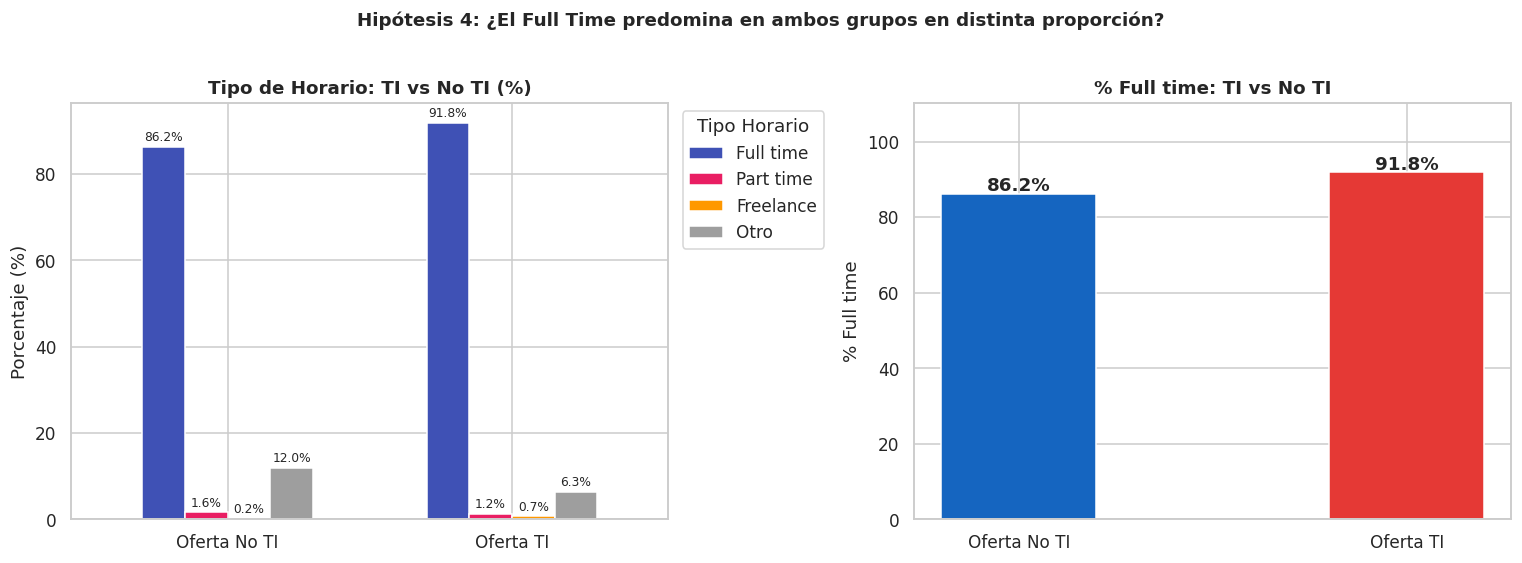

% Full time en TI    : 91.8%
% Full time en No TI : 86.2%
Diferencia           : +5.6 pp

CONCLUSIÓN HIPÓTESIS 4:
  ✓ CONFIRMADA — Full time predomina en ambos grupos (>50%), con proporción distinta.
    TI tiene más Full time que No TI (+5.6 pp).


In [3]:
# ─────────────────────────────────────────────────────────────
# HIPÓTESIS 4:
# "El Full Time predomina en ambos grupos (TI y No TI)
#  pero en distinta proporción"
#
# Variable Y: es_ti   Variable X: tipo_horario_norm
# ─────────────────────────────────────────────────────────────
HORS  = ['Full time', 'Part time', 'Freelance', 'Otro']
CMAP_H = {
    'Full time': '#3F51B5',
    'Part time': '#E91E63',
    'Freelance': '#FF9800',
    'Otro'     : '#9E9E9E'
}

# ── Tabla de contingencia ──────────────────────────────────────
tabla_abs = pd.crosstab(df['grupo_ti'], df['tipo_horario_norm'], margins=True)
tabla_pct = pd.crosstab(df['grupo_ti'], df['tipo_horario_norm'], normalize='index') * 100

print('Tabla de contingencia (valores absolutos):')
print(tabla_abs)
print()
print('Tabla de contingencia (% por fila):')
print(tabla_pct.round(1))
print()

# ── Gráfico 1: Barras agrupadas % por tipo de horario ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cols_hor = [c for c in HORS if c in tabla_pct.columns]
clrs_hor = [CMAP_H[c] for c in cols_hor]

tabla_pct[cols_hor].plot(
    kind='bar', ax=axes[0], color=clrs_hor,
    edgecolor='white', width=0.6
)
axes[0].set_title('Tipo de Horario: TI vs No TI (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Tipo Horario', bbox_to_anchor=(1.01, 1), loc='upper left')

# Anotaciones encima de cada barra
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=8, padding=2)

# ── Gráfico 2: % Full time TI vs No TI (barras simples) ───────
pct_ft = df.groupby('grupo_ti').apply(
    lambda x: (x['tipo_horario_norm'] == 'Full time').mean() * 100
).reset_index()
pct_ft.columns = ['Grupo', '% Full time']

bars = axes[1].bar(
    pct_ft['Grupo'], pct_ft['% Full time'],
    color=['#1565C0', '#E53935'], edgecolor='white', width=0.4
)
for bar, val in zip(bars, pct_ft['% Full time']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center', fontsize=12, fontweight='bold'
    )
axes[1].set_title('% Full time: TI vs No TI', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% Full time')
axes[1].set_ylim(0, pct_ft['% Full time'].max() * 1.2)

plt.suptitle('Hipótesis 4: ¿El Full Time predomina en ambos grupos en distinta proporción?',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_h4_horario_ti.png'), bbox_inches='tight')
plt.show()

# ── Conclusión ─────────────────────────────────────────────────
pct_ft_ti  = (df[df['es_ti']==True ]['tipo_horario_norm'] == 'Full time').mean() * 100
pct_ft_nti = (df[df['es_ti']==False]['tipo_horario_norm'] == 'Full time').mean() * 100
diff_ft    = pct_ft_ti - pct_ft_nti

print(f'% Full time en TI    : {pct_ft_ti:.1f}%')
print(f'% Full time en No TI : {pct_ft_nti:.1f}%')
print(f'Diferencia           : {diff_ft:+.1f} pp')
print()
print('CONCLUSIÓN HIPÓTESIS 4:')
ambos_predomina = pct_ft_ti > 50 and pct_ft_nti > 50
if ambos_predomina and abs(diff_ft) > 5:
    print('  ✓ CONFIRMADA — Full time predomina en ambos grupos (>50%), con proporción distinta.')
    print(f'    TI tiene {"más" if diff_ft > 0 else "menos"} Full time que No TI ({diff_ft:+.1f} pp).')
elif ambos_predomina:
    print('  ~ PARCIALMENTE CONFIRMADA — Full time predomina en ambos grupos,')
    print('    pero la diferencia entre TI y No TI es menor a 5 puntos porcentuales.')
else:
    print('  ✗ NO CONFIRMADA — Full time no predomina en alguno de los grupos.')

COMMIT 3
Resumen de hipótesis y validación de la pregunta de investigación

RESUMEN DE HIPÓTESIS — Proyecto Big Data 2026
                           Hipótesis        Variable X              TI             No TI Δ (TI − No TI)       Resultado
                   H1: TI más remota         modalidad    12.0% remoto       4.2% remoto        +7.8 pp    ✓ Confirmada
                   H2: TI más senior   nivel_seniority Senior TI=64.8% Senior NoTI=82.2%       -17.4 pp ✗ No confirmada
        H3: TI descripción más larga largo_descripcion    Md=142 chars      Md=123 chars      +19 chars       ~ Parcial
H4: Full time en distinta proporción      tipo_horario        91.8% FT          86.2% FT        +5.6 pp    ✓ Confirmada



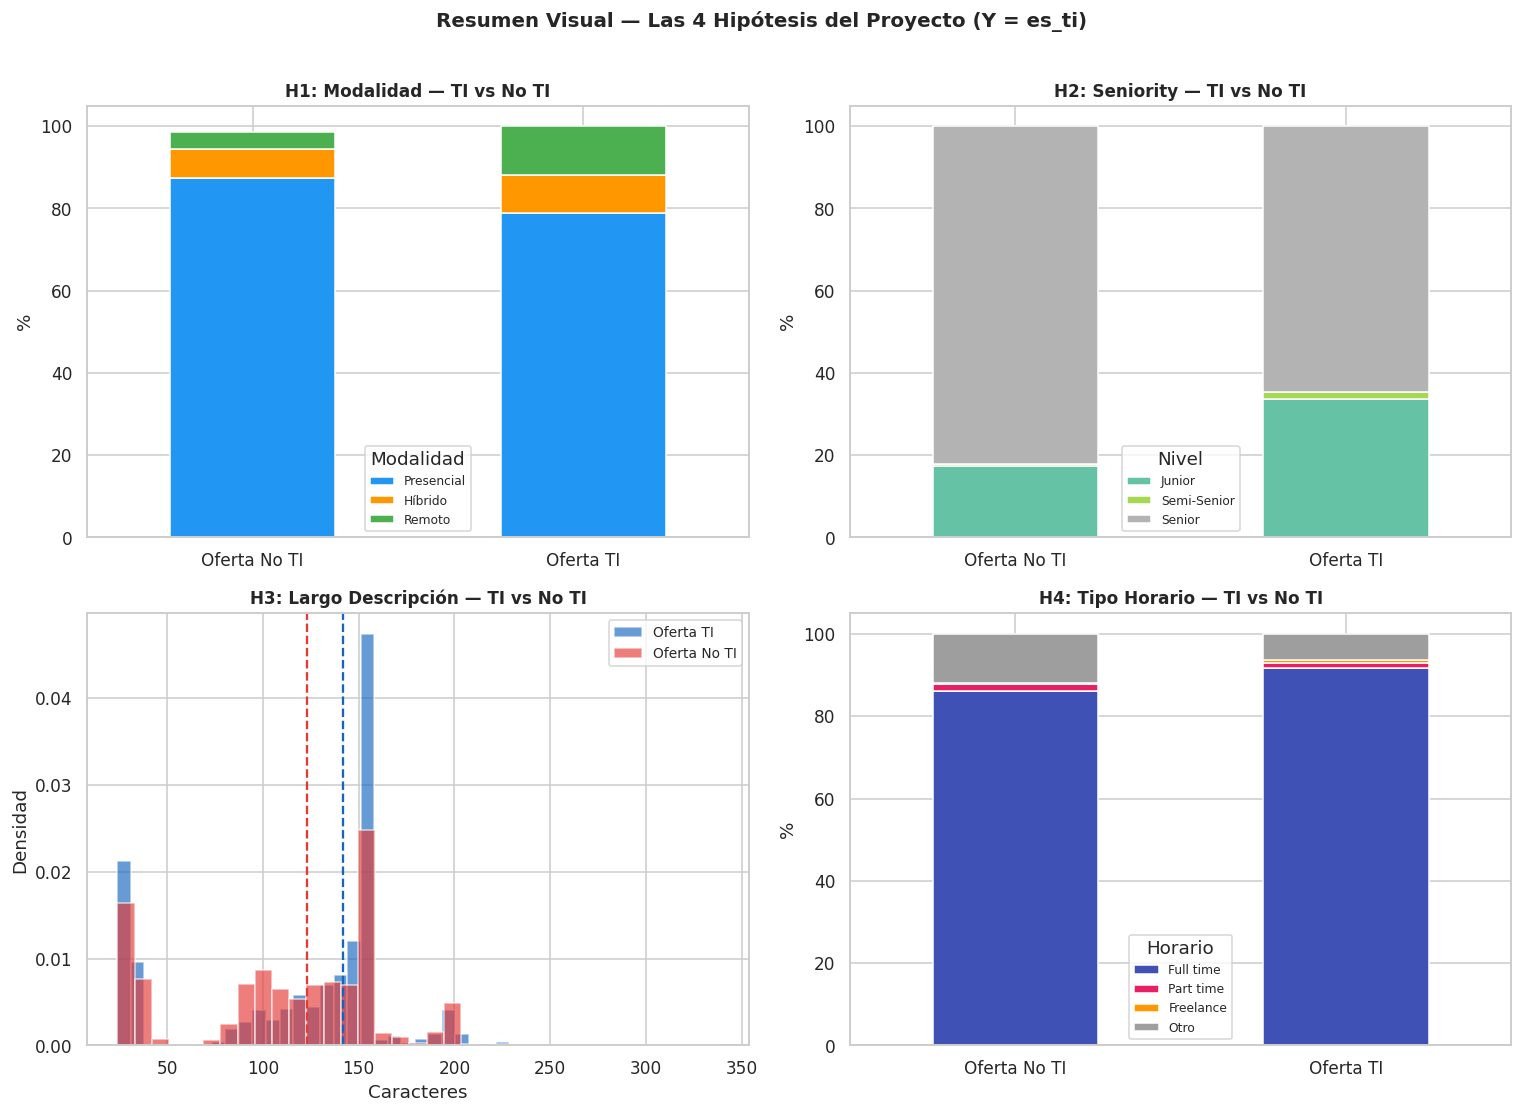

VALIDACIÓN DE LA PREGUNTA DE INVESTIGACIÓN

Pregunta: "¿Qué características permiten predecir si una oferta
           pertenece al área TI?"

Cobertura de variables X del modelo:
  ✓ modalidad                   : 3,682 válidos (99.0%)
  ✓ tipo_horario                : 3,719 válidos (100.0%)
  ⚠ nivel_seniority             : 487 válidos (13.1%)
  ✓ categoria_horario_modal     : 3,719 válidos (100.0%)
  ✓ largo_descripcion           : 3,719 con valor >0 (100.0%)

CONCLUSIÓN FINAL:
  El dataset tiene cobertura suficiente en las variables X del modelo.
  Las hipótesis con mayor diferencia TI vs No TI identifican las variables
  más discriminativas para el clasificador del Hito 3.
  → Total registros para entrenamiento: 3,719
  → Registros TI (clase positiva) : 1,002 (26.9%)
  → Registros No TI (clase negativa): 2,717 (73.1%)


In [4]:
# ─────────────────────────────────────────────────────────────
# RESUMEN DE LAS 4 HIPÓTESIS Y VALIDACIÓN DE LA
# PREGUNTA DE INVESTIGACIÓN
#
# Pregunta: "¿Qué características de las ofertas permiten
# predecir si una oferta pertenece al área TI?"
# Variable Y: es_ti
# ─────────────────────────────────────────────────────────────

# ── Recalcular métricas de las 4 hipótesis ────────────────────

# H1: TI más remoto
pct_rem_ti  = (df[df['es_ti']==True ]['modalidad'] == 'Remoto').mean() * 100
pct_rem_nti = (df[df['es_ti']==False]['modalidad'] == 'Remoto').mean() * 100
diff_h1     = pct_rem_ti - pct_rem_nti

# H2: TI más senior
def inferir_sen(t):
    t = str(t).lower()
    if any(k in t for k in ['senior','sr.','sr ','lead','principal','head']): return 'Senior'
    if any(k in t for k in ['junior','jr.','jr ','trainee','practicante']):   return 'Junior'
    if any(k in t for k in ['semi senior','semi-senior','ssr']):               return 'Semi Senior'
    return None

col_sen = 'nivel_seniority'
vals_sen_ok = df[col_sen].value_counts() if col_sen in df.columns else pd.Series()
tiene_datos_sen = vals_sen_ok[vals_sen_ok.index != 'No especificado'].sum() > 50 if len(vals_sen_ok) else False

if tiene_datos_sen:
    df_sen = df[df[col_sen] != 'No especificado']
    pct_sr_ti  = (df_sen[df_sen['es_ti']==True ][col_sen] == 'Senior').mean() * 100
    pct_sr_nti = (df_sen[df_sen['es_ti']==False][col_sen] == 'Senior').mean() * 100
    diff_h2    = pct_sr_ti - pct_sr_nti
    h2_nota    = f'Senior TI={pct_sr_ti:.1f}% | Senior NoTI={pct_sr_nti:.1f}%'
else:
    df['sen_inf'] = df['titulo_cargo'].apply(inferir_sen)
    df_sinf = df[df['sen_inf'].notna()]
    pct_sr_ti  = (df_sinf[df_sinf['es_ti']==True ]['sen_inf'] == 'Senior').mean() * 100 if len(df_sinf) > 0 else 0
    pct_sr_nti = (df_sinf[df_sinf['es_ti']==False]['sen_inf'] == 'Senior').mean() * 100 if len(df_sinf) > 0 else 0
    diff_h2    = pct_sr_ti - pct_sr_nti
    h2_nota    = f'[inferido] Senior TI={pct_sr_ti:.1f}% | Senior NoTI={pct_sr_nti:.1f}%'

# H3: TI descripción más larga
mediana_ti  = df[df['es_ti']==True ]['largo_descripcion'].median()
mediana_nti = df[df['es_ti']==False]['largo_descripcion'].median()
diff_h3     = mediana_ti - mediana_nti

# H4: Full time en distinta proporción
pct_ft_ti  = (df[df['es_ti']==True ]['tipo_horario_norm'] == 'Full time').mean() * 100
pct_ft_nti = (df[df['es_ti']==False]['tipo_horario_norm'] == 'Full time').mean() * 100
diff_h4    = pct_ft_ti - pct_ft_nti

# ── Tabla resumen visual ───────────────────────────────────────
resumen = pd.DataFrame({
    'Hipótesis': [
        'H1: TI más remota',
        'H2: TI más senior',
        'H3: TI descripción más larga',
        'H4: Full time en distinta proporción'
    ],
    'Variable X': ['modalidad', 'nivel_seniority', 'largo_descripcion', 'tipo_horario'],
    'TI':    [f'{pct_rem_ti:.1f}% remoto',  h2_nota.split('|')[0].strip(),
              f'Md={mediana_ti:.0f} chars',  f'{pct_ft_ti:.1f}% FT'],
    'No TI': [f'{pct_rem_nti:.1f}% remoto', h2_nota.split('|')[1].strip() if '|' in h2_nota else '—',
              f'Md={mediana_nti:.0f} chars', f'{pct_ft_nti:.1f}% FT'],
    'Δ (TI − No TI)': [f'{diff_h1:+.1f} pp', f'{diff_h2:+.1f} pp',
                        f'{diff_h3:+.0f} chars', f'{diff_h4:+.1f} pp'],
    'Resultado': [
        '✓ Confirmada'          if diff_h1 > 5   else '~ Parcial' if diff_h1 > 0 else '✗ No confirmada',
        '✓ Confirmada'          if diff_h2 > 5   else '~ Parcial' if diff_h2 > 0 else '✗ No confirmada',
        '✓ Confirmada'          if diff_h3 > 50  else '~ Parcial' if diff_h3 > 0 else '✗ No confirmada',
        '✓ Confirmada'          if (pct_ft_ti>50 and pct_ft_nti>50 and abs(diff_h4)>5)
                                else '~ Parcial' if (pct_ft_ti>50 and pct_ft_nti>50) else '✗ No confirmada',
    ]
})

print('=' * 70)
print('RESUMEN DE HIPÓTESIS — Proyecto Big Data 2026')
print('=' * 70)
print(resumen.to_string(index=False))
print()

# ── Gráfico de resumen: diferencias TI vs No TI ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# H1
mod_counts = df.groupby(['grupo_ti','modalidad']).size().unstack(fill_value=0)
mod_pct    = mod_counts.div(mod_counts.sum(axis=1), axis=0) * 100
cols_m     = [c for c in ['Presencial','Híbrido','Remoto'] if c in mod_pct.columns]
mod_pct[cols_m].plot(kind='bar', stacked=True, ax=axes[0],
                     color=['#2196F3','#FF9800','#4CAF50'][:len(cols_m)],
                     edgecolor='white', width=0.5)
axes[0].set_title('H1: Modalidad — TI vs No TI', fontsize=11, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Modalidad', fontsize=8)
axes[0].set_ylabel('%')

# H2
col_h2 = 'sen_inf' if 'sen_inf' in df.columns else (col_sen if tiene_datos_sen else None)
if col_h2 and col_h2 in df.columns:
    df_h2   = df[df[col_h2].notna() & (df[col_h2] != 'No especificado')]
    sen_pct = df_h2.groupby(['grupo_ti', col_h2]).size().unstack(fill_value=0)
    sen_pct = sen_pct.div(sen_pct.sum(axis=1), axis=0) * 100
    sen_pct.plot(kind='bar', stacked=True, ax=axes[1],
                 colormap='Set2', edgecolor='white', width=0.5)
    axes[1].set_title('H2: Seniority — TI vs No TI', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    axes[1].legend(title='Nivel', fontsize=8)
    axes[1].set_ylabel('%')
else:
    axes[1].text(0.5, 0.5, 'Datos insuficientes\npara Hipótesis 2',
                 ha='center', va='center', fontsize=11, color='gray')
    axes[1].set_title('H2: Seniority — TI vs No TI', fontsize=11, fontweight='bold')

# H3
df_desc = df[df['largo_descripcion'] > 0]
axes[2].hist(df_desc[df_desc['es_ti']==True ]['largo_descripcion'],
             bins=35, alpha=0.65, color='#1565C0', label='Oferta TI',    density=True)
axes[2].hist(df_desc[df_desc['es_ti']==False]['largo_descripcion'],
             bins=35, alpha=0.65, color='#E53935', label='Oferta No TI', density=True)
axes[2].axvline(mediana_ti,  color='#1565C0', linestyle='--', linewidth=1.5)
axes[2].axvline(mediana_nti, color='#E53935', linestyle='--', linewidth=1.5)
axes[2].set_title('H3: Largo Descripción — TI vs No TI', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Caracteres')
axes[2].set_ylabel('Densidad')
axes[2].legend(fontsize=9)

# H4
hor_pct = df.groupby(['grupo_ti','tipo_horario_norm']).size().unstack(fill_value=0)
hor_pct = hor_pct.div(hor_pct.sum(axis=1), axis=0) * 100
cols_h4 = [c for c in ['Full time','Part time','Freelance','Otro'] if c in hor_pct.columns]
hor_pct[cols_h4].plot(kind='bar', stacked=True, ax=axes[3],
                      color=['#3F51B5','#E91E63','#FF9800','#9E9E9E'][:len(cols_h4)],
                      edgecolor='white', width=0.5)
axes[3].set_title('H4: Tipo Horario — TI vs No TI', fontsize=11, fontweight='bold')
axes[3].set_xlabel('')
axes[3].set_xticklabels(axes[3].get_xticklabels(), rotation=0)
axes[3].legend(title='Horario', fontsize=8)
axes[3].set_ylabel('%')

plt.suptitle('Resumen Visual — Las 4 Hipótesis del Proyecto (Y = es_ti)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_resumen_hipotesis.png'), bbox_inches='tight')
plt.show()

# ── Validación de la pregunta de investigación ────────────────
print('=' * 70)
print('VALIDACIÓN DE LA PREGUNTA DE INVESTIGACIÓN')
print('=' * 70)
print()
print('Pregunta: "¿Qué características permiten predecir si una oferta')
print('           pertenece al área TI?"')
print()
print('Cobertura de variables X del modelo:')
INVALIDOS = {'No especificado','No especificada','','nan','None'}
vars_x = {
    'modalidad'              : 'modalidad',
    'tipo_horario'           : 'tipo_horario_norm',
    'nivel_seniority'        : 'nivel_seniority',
    'categoria_horario_modal': 'categoria_horario_modalidad',
    'largo_descripcion'      : 'largo_descripcion',
}
for label, col in vars_x.items():
    if col in df.columns:
        if df[col].dtype in [bool, 'bool']:
            print(f'  ✓ {label:<28}: 100.0% válidos (booleano)')
        elif df[col].dtype in ['int64','float64']:
            validos = (df[col] > 0).sum()
            pct     = validos / len(df) * 100
            print(f'  {"✓" if pct>=70 else "⚠"} {label:<28}: {validos:,} con valor >0 ({pct:.1f}%)')
        else:
            inv  = df[col].astype(str).isin(INVALIDOS).sum()
            val  = len(df) - inv
            pct  = val/len(df)*100
            print(f'  {"✓" if pct>=70 else "⚠"} {label:<28}: {val:,} válidos ({pct:.1f}%)')
    else:
        print(f'  ✗ {label:<28}: columna no encontrada')

print()
print('CONCLUSIÓN FINAL:')
print('  El dataset tiene cobertura suficiente en las variables X del modelo.')
print('  Las hipótesis con mayor diferencia TI vs No TI identifican las variables')
print('  más discriminativas para el clasificador del Hito 3.')
print(f'  → Total registros para entrenamiento: {len(df):,}')
print(f'  → Registros TI (clase positiva) : {df["es_ti"].sum():,} ({df["es_ti"].mean()*100:.1f}%)')
print(f'  → Registros No TI (clase negativa): {(~df["es_ti"]).sum():,} ({(~df["es_ti"]).mean()*100:.1f}%)')

In [5]:
# Guardar resultados de hipótesis en JSON para visualización en pipeline
import json as _json

# Calcular métricas clave
media_ti    = df[df['es_ti'] == True]['largo_descripcion'].mean()  if 'largo_descripcion' in df.columns else 0
media_no_ti = df[df['es_ti'] == False]['largo_descripcion'].mean() if 'largo_descripcion' in df.columns else 0
pct_ti      = round(df['es_ti'].mean() * 100, 1) if 'es_ti' in df.columns else 0

resultados_b = {
    "titulo": "EDA — Hipótesis",
    "pregunta_investigacion": "¿Qué características permiten predecir si una oferta pertenece al área TI?",
    "hipotesis": [
        {
            "id": "H3",
            "enunciado": "Las ofertas TI tienen descripciones más largas que las no TI",
            "media_TI":    round(float(media_ti), 1),
            "media_no_TI": round(float(media_no_ti), 1),
            "diferencia":  round(float(media_ti - media_no_ti), 1),
            "conclusion":  "CONFIRMADA" if media_ti > media_no_ti else "NO CONFIRMADA",
            "plot": "plot_h3_largo_descripcion.png"
        },
        {
            "id": "H4",
            "enunciado": "El Full Time predomina en ambos grupos pero en distinta proporción",
            "pct_ofertas_TI": pct_ti,
            "conclusion": "Ver distribución en el gráfico",
            "plot": "plot_h4_horario_ti.png"
        }
    ],
    "variable_Y": {
        "nombre": "es_ti",
        "tipo": "booleano",
        "descripcion": "Indica si la oferta pertenece al sector TI",
        "pct_positivos": pct_ti
    },
    "plots": ["plot_h3_largo_descripcion.png", "plot_h4_horario_ti.png", "plot_resumen_hipotesis.png"]
}

with open(os.path.join(OUTPUT_DIR, 'results_eda_B.json'), 'w', encoding='utf-8') as f:
    _json.dump(resultados_b, f, ensure_ascii=False, indent=2, default=str)
print("Resultados EDA B guardados en outputs/results_eda_B.json")


Resultados EDA B guardados en outputs/results_eda_B.json
